# Análisis de Seguridad — Resumen General

Notebook principal del pipeline. Consolida los resultados de todas las herramientas
(CodeQL, Grype, Gitleaks, Syft) y calcula una puntuación de riesgo por repositorio.

**Fuente de datos:** `/data/secpipeline.json` generado por el Miner.

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns

# ── Configuración ──────────────────────────────────────────────────────────────
DB_PATH = os.getenv("DB_PATH", "/data/secpipeline.json")
# Fallback para desarrollo local
if not Path(DB_PATH).exists():
    DB_PATH = str(Path("../data/secpipeline.json").resolve())

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (12, 5)

SEV_ORDER   = ["critical", "high", "medium", "low", "negligible", "unknown"]
SEV_PALETTE = {
    "critical":   "#d62728",
    "high":       "#ff7f0e",
    "medium":     "#bcbd22",
    "low":        "#2ca02c",
    "negligible": "#aec7e8",
    "unknown":    "#c7c7c7",
}
SEV_WEIGHTS = {"critical": 10, "high": 5, "medium": 2, "low": 1, "negligible": 0}

print(f"Cargando dataset desde: {DB_PATH}")

Cargando dataset desde: /data/secpipeline.json


In [2]:
# ── Carga del dataset ──────────────────────────────────────────────────────────
with open(DB_PATH) as f:
    db = json.load(f)

repos      = pd.DataFrame(db.get("repositories", []))
codeql     = pd.DataFrame(db.get("codeql_findings", []))
grype      = pd.DataFrame(db.get("grype_findings", []))
gitleaks   = pd.DataFrame(db.get("gitleaks_findings", []))
sbom       = pd.DataFrame(db.get("sbom_components", []))

codeql_sc  = pd.DataFrame(db.get("codeql_scans", []))
grype_sc   = pd.DataFrame(db.get("grype_scans", []))
gitleaks_sc = pd.DataFrame(db.get("gitleaks_scans", []))
sbom_sc    = pd.DataFrame(db.get("sbom_scans", []))

# Mapa id → nombre completo del repo
repo_names = repos.set_index("id")["full_name"].to_dict() if not repos.empty else {}

print(f"Repositorios registrados : {len(repos)}")
print(f"Hallazgos CodeQL         : {len(codeql)}")
print(f"Hallazgos Grype (CVE)    : {len(grype)}")
print(f"Secretos Gitleaks        : {len(gitleaks)}")
print(f"Componentes SBOM         : {len(sbom)}")

NameError: name 'DB_PATH' is not defined

## 1. Estado del Pipeline

Distribución de estados de los repositorios: cuántos fueron clonados y analizados correctamente.

In [3]:
if repos.empty:
    print("No hay datos de repositorios todavía. Ejecutá el miner primero.")
else:
    status_counts = repos["miner_status"].value_counts()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Gráfico de torta
    colors = {"cloned": "#2ca02c", "error": "#d62728", "pending": "#aec7e8", "cloning": "#ff7f0e"}
    pie_colors = [colors.get(s, "#c7c7c7") for s in status_counts.index]
    axes[0].pie(status_counts, labels=status_counts.index, autopct="%1.1f%%",
                colors=pie_colors, startangle=90)
    axes[0].set_title("Estado de repositorios")

    # Escaneos por herramienta
    tool_data = {
        "CodeQL": len(codeql_sc),
        "Grype": len(grype_sc),
        "Gitleaks": len(gitleaks_sc),
        "SBOM (Syft)": len(sbom_sc),
    }
    axes[1].bar(tool_data.keys(), tool_data.values(),
                color=["#1f77b4", "#ff7f0e", "#d62728", "#2ca02c"])
    axes[1].set_title("Escaneos realizados por herramienta")
    axes[1].set_ylabel("Cantidad de escaneos")
    for i, (k, v) in enumerate(tool_data.items()):
        axes[1].text(i, v + 0.2, str(v), ha="center", fontweight="bold")

    plt.suptitle("Estado general del pipeline", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

    print("\nDistribución de estados:")
    print(status_counts.to_string())

NameError: name 'repos' is not defined

## 2. Hallazgos por Herramienta

Total de hallazgos encontrados por cada herramienta de análisis.

In [4]:
tool_findings = {
    "CodeQL": len(codeql),
    "Grype (CVE)": len(grype),
    "Gitleaks (secretos)": len(gitleaks),
    "SBOM (componentes)": len(sbom),
}

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(list(tool_findings.keys()), list(tool_findings.values()),
               color=["#1f77b4", "#ff7f0e", "#d62728", "#9467bd"])
ax.set_xlabel("Cantidad de hallazgos")
ax.set_title("Total de hallazgos por herramienta", fontsize=13, fontweight="bold")
for bar, val in zip(bars, tool_findings.values()):
    ax.text(bar.get_width() + max(tool_findings.values()) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", fontweight="bold")
plt.tight_layout()
plt.show()

NameError: name 'codeql' is not defined

## 3. Distribución de Severidad General

Agregamos los hallazgos de CodeQL y Grype (los que tienen severidad clasificada)
para ver la distribución total de riesgo.

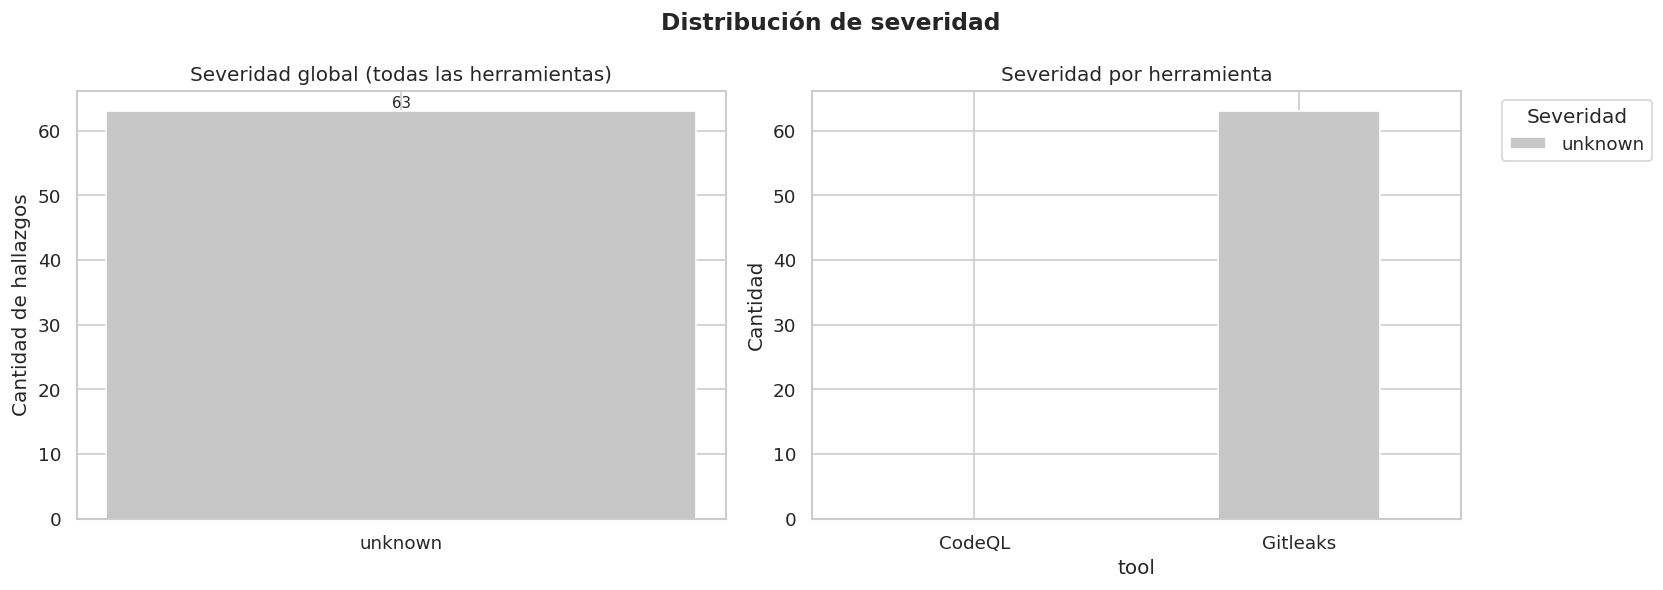

In [ ]:
sev_frames = []
if not codeql.empty and "severity" in codeql.columns:
    sev_frames.append(codeql[["severity"]].assign(tool="CodeQL"))
if not grype.empty and "severity" in grype.columns:
    sev_frames.append(grype[["severity"]].assign(tool="Grype"))
if not gitleaks.empty and "severity" in gitleaks.columns:
    tmp = gitleaks[["severity"]].copy()
    tmp["severity"] = tmp["severity"].fillna("unknown")
    sev_frames.append(tmp.assign(tool="Gitleaks"))

if not sev_frames:
    print("No hay datos de severidad disponibles todavía.")
else:
    all_sev = pd.concat(sev_frames, ignore_index=True)
    all_sev["severity"] = all_sev["severity"].str.lower().fillna("unknown")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Global
    sev_total = all_sev["severity"].value_counts().reindex(
        [s for s in SEV_ORDER if s in all_sev["severity"].values], fill_value=0
    )
    bar_colors = [SEV_PALETTE.get(s, "#c7c7c7") for s in sev_total.index]
    axes[0].bar(sev_total.index, sev_total.values, color=bar_colors)
    axes[0].set_title("Severidad global (todas las herramientas)")
    axes[0].set_ylabel("Cantidad de hallazgos")
    for i, v in enumerate(sev_total.values):
        axes[0].text(i, v + 0.5, str(v), ha="center", fontsize=9)

    # Por herramienta (stacked)
    pivot = all_sev.groupby(["tool", "severity"]).size().unstack(fill_value=0)
    ordered_cols = [c for c in SEV_ORDER if c in pivot.columns]
    pivot[ordered_cols].plot(
        kind="bar", stacked=True, ax=axes[1],
        color=[SEV_PALETTE.get(c, "#c7c7c7") for c in ordered_cols]
    )
    axes[1].set_title("Severidad por herramienta")
    axes[1].set_ylabel("Cantidad")
    axes[1].tick_params(axis="x", rotation=0)
    axes[1].legend(title="Severidad", bbox_to_anchor=(1.05, 1))

    plt.suptitle("Distribución de severidad", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

## 4. Top 15 Repositorios por Total de Hallazgos

Repositorios con mayor cantidad acumulada de vulnerabilidades detectadas.

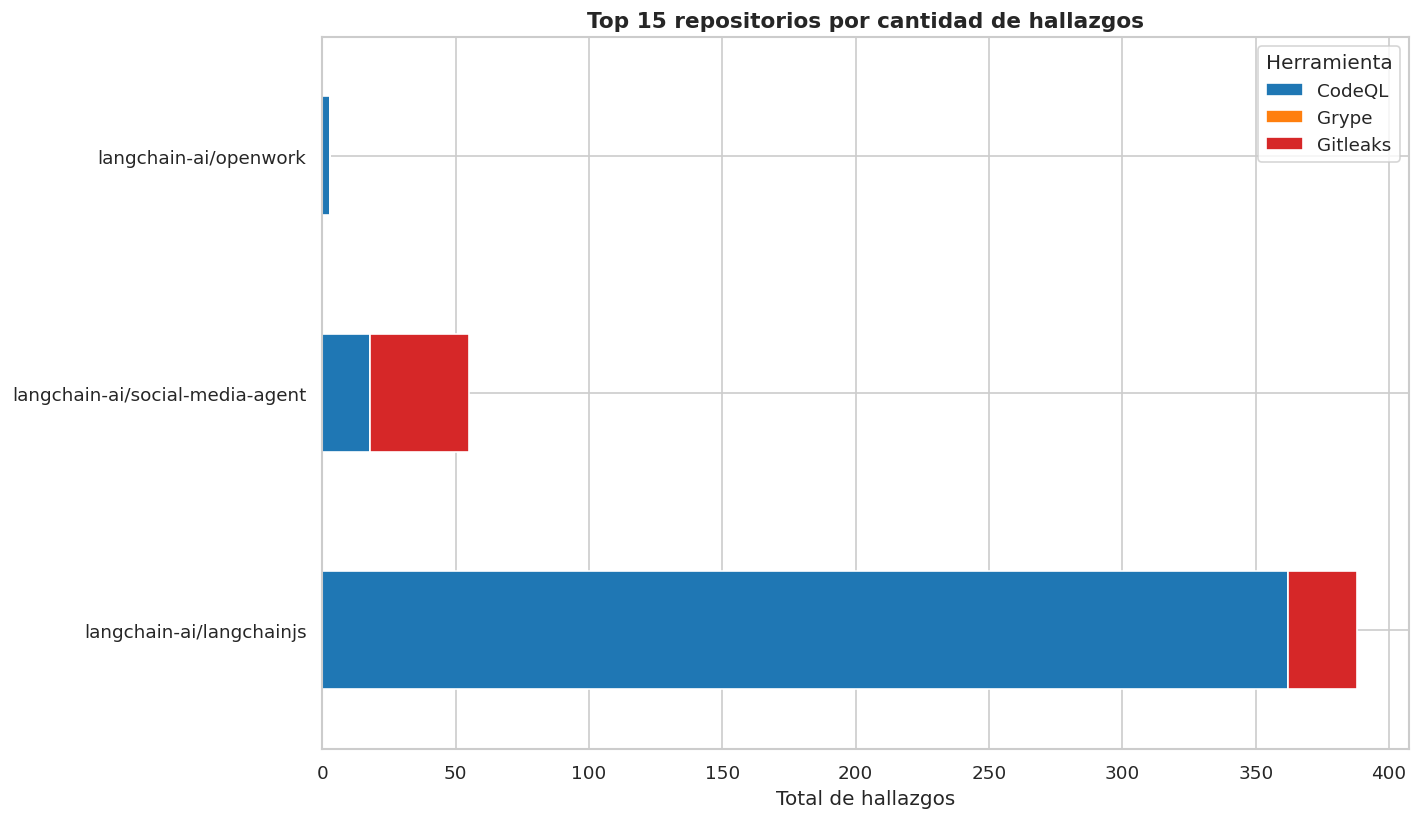

In [ ]:
def count_by_repo(df, col="repo_id"):
    if df.empty or col not in df.columns:
        return pd.Series(dtype=int)
    return df.groupby(col).size()

counts = pd.DataFrame({
    "CodeQL":   count_by_repo(codeql),
    "Grype":    count_by_repo(grype),
    "Gitleaks": count_by_repo(gitleaks),
}).fillna(0).astype(int)

if counts.empty:
    print("No hay hallazgos para mostrar todavía.")
else:
    counts["total"] = counts.sum(axis=1)
    counts.index = counts.index.map(lambda i: repo_names.get(i, f"repo_{i}"))
    top = counts.nlargest(15, "total")

    fig, ax = plt.subplots(figsize=(12, 7))
    top[["CodeQL", "Grype", "Gitleaks"]].plot(
        kind="barh", stacked=True, ax=ax,
        color=["#1f77b4", "#ff7f0e", "#d62728"]
    )
    ax.set_xlabel("Total de hallazgos")
    ax.set_title("Top 15 repositorios por cantidad de hallazgos", fontsize=13, fontweight="bold")
    ax.legend(title="Herramienta")
    plt.tight_layout()
    plt.show()

## 5. Puntuación de Riesgo por Repositorio

Score compuesto que pondera la severidad de cada hallazgo:
- Critical: 10 pts | High: 5 pts | Medium: 2 pts | Low: 1 pt
- Secreto Gitleaks: 3 pts (riesgo fijo por ausencia de severidad estandarizada)

Permite comparar repositorios más allá del volumen bruto de hallazgos.

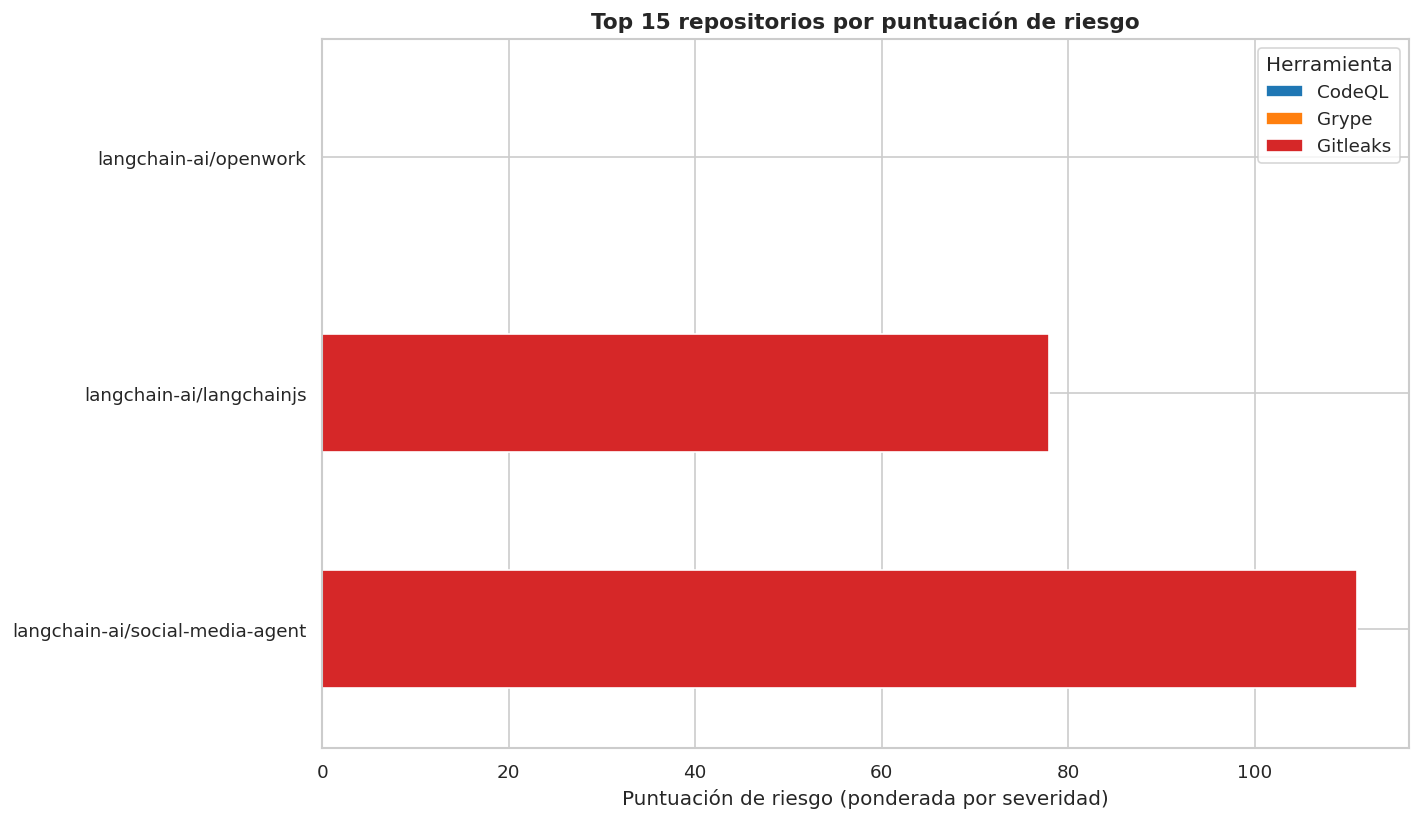


Ranking completo de riesgo:
                                 Score CodeQL  Score Grype  Score Gitleaks  Score Total
langchain-ai/social-media-agent           0.0          0.0           111.0        111.0
langchain-ai/langchainjs                  0.0          0.0            78.0         78.0
langchain-ai/openwork                     0.0          0.0             0.0          0.0


In [ ]:
def weighted_score(df, weight_col="severity", secret_weight=3):
    """Suma pesos de severidad por repo_id."""
    if df.empty or "repo_id" not in df.columns:
        return pd.Series(dtype=float)
    if weight_col in df.columns:
        tmp = df[["repo_id", weight_col]].copy()
        tmp[weight_col] = tmp[weight_col].str.lower().fillna("unknown")
        tmp["score"] = tmp[weight_col].map(SEV_WEIGHTS).fillna(0)
    else:
        tmp = df[["repo_id"]].copy()
        tmp["score"] = secret_weight
    return tmp.groupby("repo_id")["score"].sum()

risk = pd.DataFrame({
    "CodeQL":   weighted_score(codeql),
    "Grype":    weighted_score(grype),
    "Gitleaks": weighted_score(gitleaks, weight_col="_none_"),
}).fillna(0)

if risk.empty:
    print("No hay datos para calcular scores todavía.")
else:
    risk["total_score"] = risk.sum(axis=1)
    risk.index = risk.index.map(lambda i: repo_names.get(i, f"repo_{i}"))
    top_risk = risk.nlargest(15, "total_score")

    fig, ax = plt.subplots(figsize=(12, 7))
    top_risk[["CodeQL", "Grype", "Gitleaks"]].plot(
        kind="barh", stacked=True, ax=ax,
        color=["#1f77b4", "#ff7f0e", "#d62728"]
    )
    ax.set_xlabel("Puntuación de riesgo (ponderada por severidad)")
    ax.set_title("Top 15 repositorios por puntuación de riesgo", fontsize=13, fontweight="bold")
    ax.legend(title="Herramienta")
    plt.tight_layout()
    plt.show()

    print("\nRanking completo de riesgo:")
    display_df = risk.sort_values("total_score", ascending=False)[["CodeQL", "Grype", "Gitleaks", "total_score"]].copy()
    display_df.columns = ["Score CodeQL", "Score Grype", "Score Gitleaks", "Score Total"]
    print(display_df.to_string())

## 6. Tabla Resumen del Análisis

In [ ]:
if not repos.empty:
    summary = repos[["full_name", "language", "stars", "miner_status"]].copy()
    summary.columns = ["Repositorio", "Lenguaje", "Stars", "Estado"]

    # Agregar conteos por herramienta
    def get_count(df, repo_id):
        if df.empty or "repo_id" not in df.columns:
            return 0
        return int((df["repo_id"] == repo_id).sum())

    summary["CodeQL"]    = repos["id"].apply(lambda i: get_count(codeql, i))
    summary["CVE"]       = repos["id"].apply(lambda i: get_count(grype, i))
    summary["Secretos"]  = repos["id"].apply(lambda i: get_count(gitleaks, i))
    summary["SBOM"]      = repos["id"].apply(lambda i: get_count(sbom, i))
    summary["Total"]     = summary["CodeQL"] + summary["CVE"] + summary["Secretos"]

    summary = summary.sort_values("Total", ascending=False)
    print(f"Resumen de {len(summary)} repositorios analizados:\n")
    print(summary.to_string(index=False))

Resumen de 3 repositorios analizados:

                    Repositorio   Lenguaje  Stars Estado  CodeQL  CVE  Secretos  SBOM  Total
       langchain-ai/langchainjs TypeScript  17608 cloned     362    0        26  2135    388
langchain-ai/social-media-agent TypeScript   2539 cloned      18    0        37  1021     55
          langchain-ai/openwork TypeScript   1395 cloned       3    0         0   725      3
